# Laboratorio 3. Preprocesamiento de las imagenes

Fabian Prado Dluzniewski 23427

Abby Donis 22440

Hansel Lopez 19026

Este notebook cubre el ejercicio 3. Documenta y justifica cada transformacion
aplicada a las imagenes antes de entrenar, y deja los tensores listos para los
modelos.

Parte de la division guardada por `01_EDA.ipynb` en `data/division.csv`, asi que
ese notebook debe correrse primero.

### IMPORTS

In [1]:
import logging
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image, ImageFilter, ImageOps
from torch.utils.data import DataLoader, Dataset

import kagglehub

logging.getLogger("kagglehub").setLevel(logging.CRITICAL)
plt.style.use("seaborn-v0_8-whitegrid")

### CONFIGURACION

In [2]:
DATASET = "grassknoted/asl-alphabet"
LADO = 64
SEMILLA = 42

DIR_DATOS = Path("./data")
DIR_PROC = DIR_DATOS / "procesado"
DIR_PROC.mkdir(parents=True, exist_ok=True)

torch.manual_seed(SEMILLA)
np.random.seed(SEMILLA)

DISPOSITIVO = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"dispositivo: {DISPOSITIVO}")

CLASES = [chr(c) for c in range(ord("A"), ord("Z") + 1)] + ["space", "del", "nothing"]
IDX_CLASE = {c: i for i, c in enumerate(CLASES)}

division = pd.read_csv(DIR_DATOS / "division.csv")
print(f"registros en la division: {len(division):,}")
print(division.groupby("grupo").size().to_string())

dispositivo: mps
registros en la division: 17,400
grupo
test      2610
train    12180
val       2610


## 3.1. Submuestra y justificacion

El dataset completo tiene 87,000 imagenes de 200x200 a color. Entrenar varias
arquitecturas sobre esa cantidad no cabe en el tiempo del laboratorio, y el
enunciado autoriza trabajar con una submuestra.

Se usan 600 imagenes por clase, 17,400 en total, dentro del rango de 500 a 800
que sugiere el enunciado. La eleccion responde a tres razones.

Primero, el dataset esta perfectamente balanceado, asi que tomar la misma
cantidad por clase conserva esa propiedad y no introduce sesgo.

Segundo, el analisis exploratorio mostro que las imagenes consecutivas de una
clase son cuadros contiguos del mismo video y por lo tanto casi identicas. La
informacion nueva por imagen adicional decae rapido, de modo que pasar de 600 a
3,000 por clase aporta mucho menos de lo que sugiere el conteo.

Tercero, la submuestra se tomo al azar sobre el rango completo de cada clase y
no en bloques contiguos, con lo que cubre toda la sesion de grabacion y toda su
variacion de iluminacion y distancia.

## 3.2. Reduccion de resolucion

Se baja de 200x200 a 64x64. La comparacion visual sirve para confirmar que la
pose de la mano sigue siendo distinguible al tamano elegido.

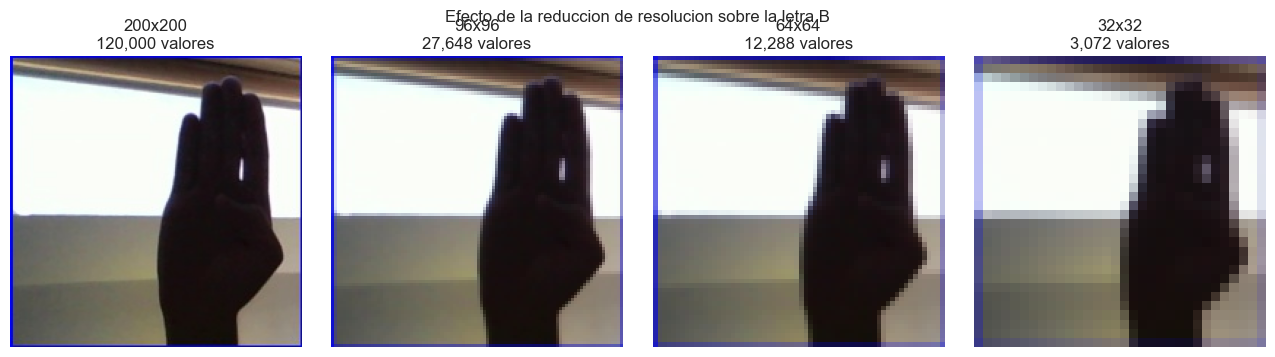

reduccion de datos de 200 a 64: 89.8 por ciento menos valores por imagen


In [3]:
RAIZ = Path(kagglehub.dataset_download(DATASET))
ejemplo = Image.open(division.loc[division["clase"] == "B", "ruta"].iloc[0])

tamanos = [200, 96, 64, 32]
fig, axes = plt.subplots(1, len(tamanos), figsize=(13, 3.6))
for ax, lado in zip(axes, tamanos):
    ax.imshow(ejemplo.resize((lado, lado), Image.BILINEAR))
    ax.set_title(f"{lado}x{lado}\n{lado*lado*3:,} valores")
    ax.axis("off")
fig.suptitle("Efecto de la reduccion de resolucion sobre la letra B", fontsize=12)
plt.tight_layout()
plt.show()

print(f"reduccion de datos de 200 a {LADO}: "
      f"{(1 - (LADO**2)/(200**2))*100:.1f} por ciento menos valores por imagen")

A 64x64 la silueta de la mano y la separacion entre dedos siguen siendo
legibles. A 32x32 los dedos empiezan a fundirse, que es justo la informacion
que distingue los grupos confundibles como U y V. Por eso 64 es el punto donde
se gana velocidad sin perder lo que el problema necesita.

La interpolacion es bilineal. Al reducir tamano evita el aliasing que produce
el vecino mas cercano, sin el costo de metodos de mayor orden.

## 3.3. Filtros evaluados

Se comparan cuatro tratamientos sobre la misma imagen para decidir cuales
entran al pipeline final.

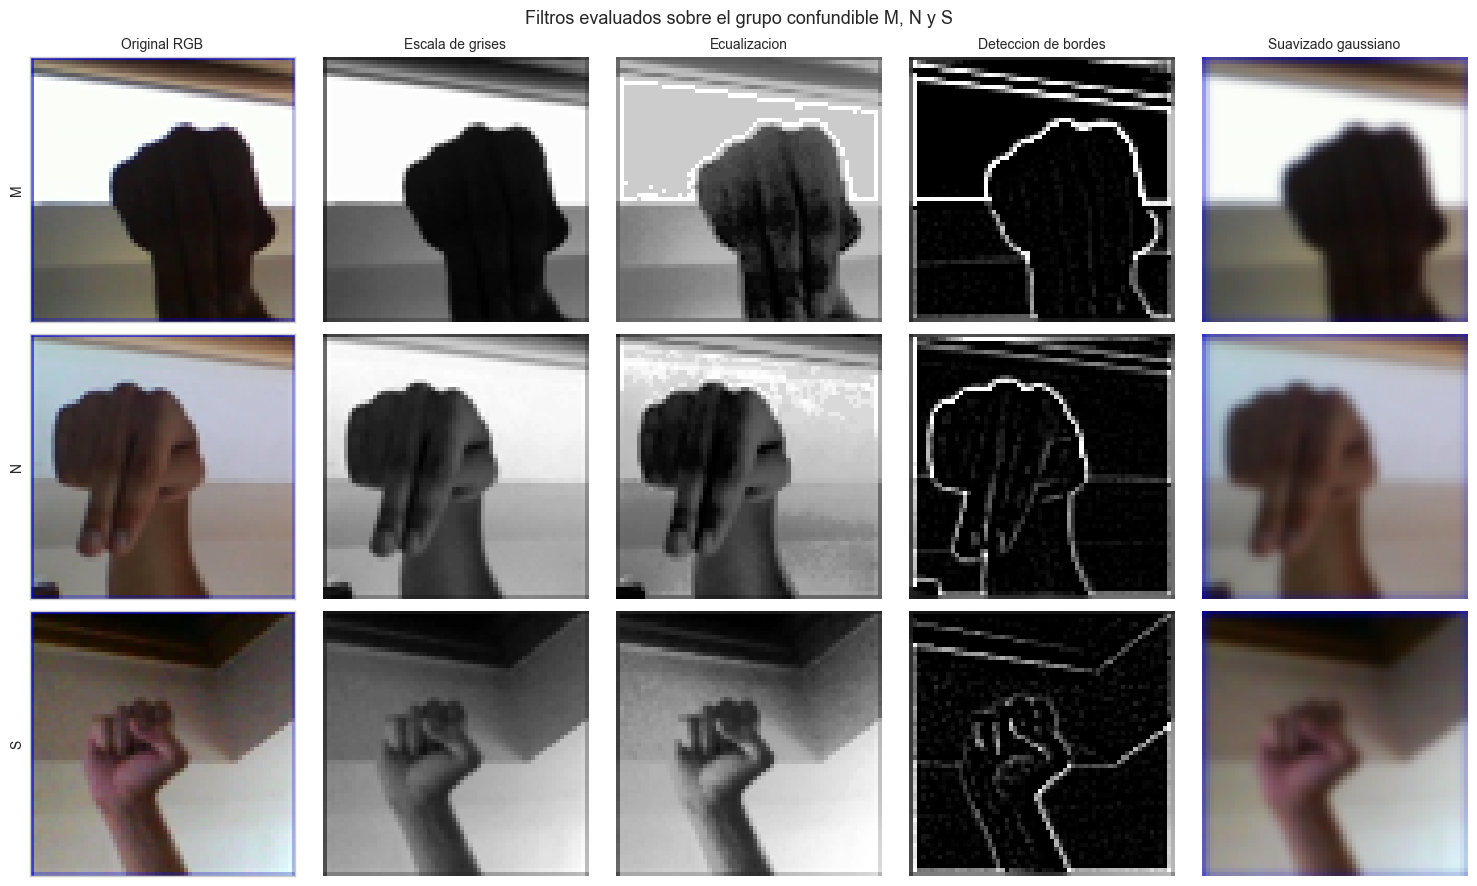

In [4]:
def a_gris(im):
    return im.convert("L")


def ecualizar(im):
    return ImageOps.equalize(im.convert("L"))


def bordes(im):
    return im.convert("L").filter(ImageFilter.FIND_EDGES)


def suavizar(im):
    return im.filter(ImageFilter.GaussianBlur(radius=1))


tratamientos = [
    ("Original RGB", lambda im: im, None),
    ("Escala de grises", a_gris, "gray"),
    ("Ecualizacion", ecualizar, "gray"),
    ("Deteccion de bordes", bordes, "gray"),
    ("Suavizado gaussiano", suavizar, None),
]

letras_demo = ["M", "N", "S"]
fig, axes = plt.subplots(len(letras_demo), len(tratamientos), figsize=(15, 9))
for i, letra in enumerate(letras_demo):
    base = Image.open(division.loc[division["clase"] == letra, "ruta"].iloc[0]).resize((LADO, LADO))
    for j, (nombre, fn, cmap) in enumerate(tratamientos):
        axes[i, j].imshow(fn(base), cmap=cmap)
        axes[i, j].axis("off")
        if i == 0:
            axes[i, j].set_title(nombre, fontsize=10)
        if j == 0:
            axes[i, j].set_ylabel(letra)
            axes[i, j].axis("on")
            axes[i, j].set_xticks([])
            axes[i, j].set_yticks([])
fig.suptitle("Filtros evaluados sobre el grupo confundible M, N y S", fontsize=13)
plt.tight_layout()
plt.show()

**Decision sobre cada filtro.**

*Escala de grises.* Se descarta como transformacion unica. Reduce la entrada a
un tercio, pero el color separa la mano del fondo y esa es informacion util
cuando la iluminacion cambia. Se conserva RGB.

*Ecualizacion de histograma.* Se descarta del pipeline base. El analisis
exploratorio mostro que la iluminacion ya es bastante uniforme porque todo se
grabo en una sola sesion, asi que la ecualizacion corrige un problema que este
dataset no tiene y amplifica el ruido del fondo. Es candidata a reevaluarse
cuando se prueben las fotos propias del ejercicio 8, donde la iluminacion si
varia.

*Deteccion de bordes.* Se descarta. Conserva el contorno pero pierde el relleno
de la palma, y en el grupo M, N y S la diferencia esta justo en la posicion del
pulgar sobre los dedos doblados, que el filtro borra.

*Suavizado gaussiano.* Se descarta del pipeline base. Las imagenes ya tienen
poco ruido y el suavizado elimina la separacion fina entre dedos. Tiene sentido
como aumento de datos, no como preprocesamiento fijo.

El pipeline final se queda con redimension a 64x64 en RGB mas normalizacion.
La ganancia esperada de los filtros no compensa la informacion que quitan.